#  EDA
This notebook explores defect types, class distribution, feature maps, and PatchCore coreset projections.

In [2]:
from pathlib import Path
import random, sys
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader

sys.path.insert(0, str(Path.cwd().parent))
from src.utils import set_seed

set_seed(42)
DATA_ROOT = Path('../data/')

torch.cuda.is_available()

False

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

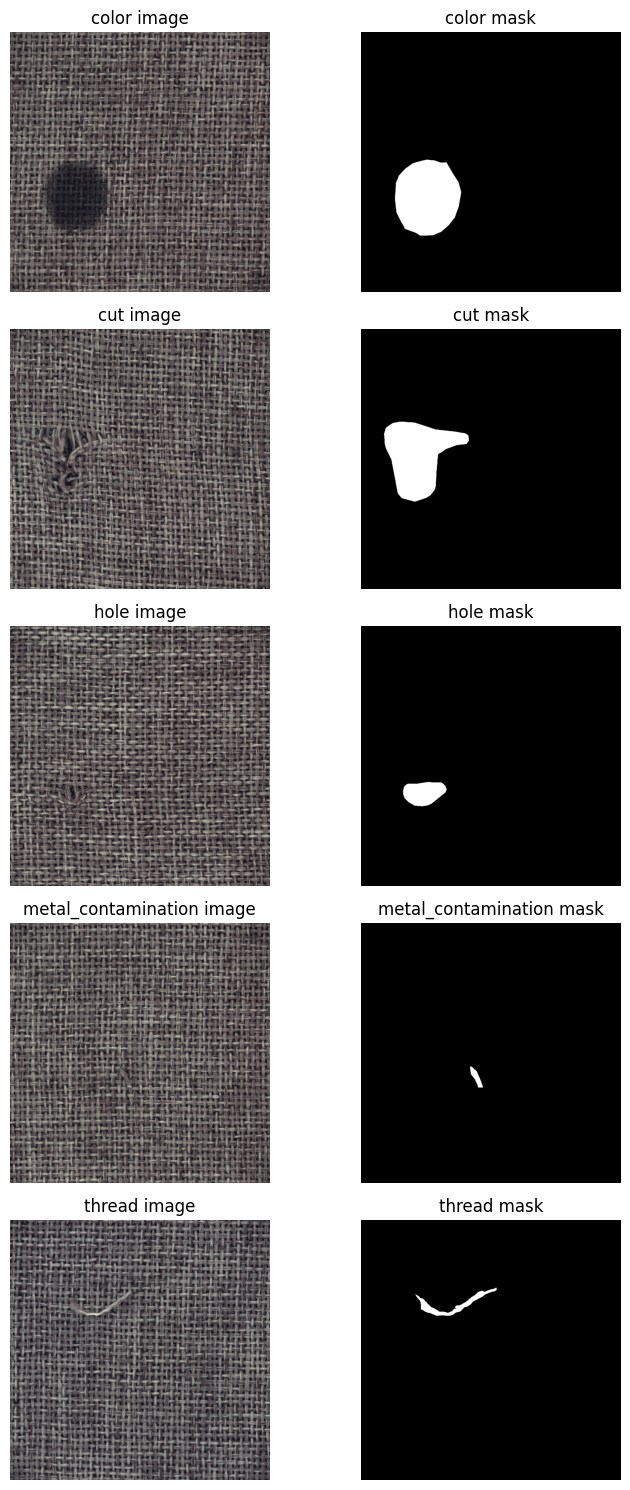

In [4]:
test_root = DATA_ROOT / 'test'
gt_root = DATA_ROOT / 'ground_truth'
defect_types = [d.name for d in sorted(test_root.iterdir()) if d.is_dir() and d.name != 'good']
fig, axes = plt.subplots(len(defect_types), 2, figsize=(8, 3 * len(defect_types)))
for row, defect in enumerate(defect_types):
    img_path = sorted((test_root / defect).glob('*.png'))[0]
    stem = img_path.stem
    mask_candidates = [gt_root / defect / f'{stem}_mask.png', gt_root / defect / f'{stem}.png']
    mask_path = next((p for p in mask_candidates if p.exists()), None)

    image = np.array(Image.open(img_path).convert('RGB'))
    mask = np.array(Image.open(mask_path).convert('L')) if mask_path is not None else np.zeros(image.shape[:2], dtype=np.uint8)

    axes[row, 0].imshow(image)
    axes[row, 0].set_title(f'{defect} image')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(mask, cmap='gray')
    axes[row, 1].set_title(f'{defect} mask')
    axes[row, 1].axis('off')

plt.tight_layout()

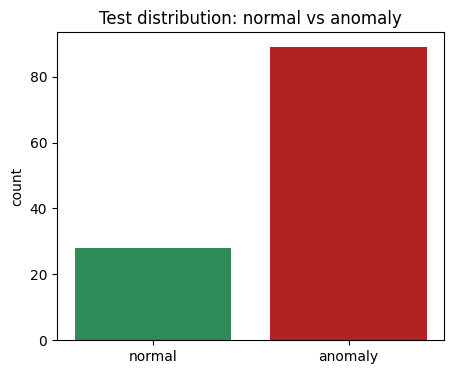

In [5]:
good_count = len(list((test_root / 'good').glob('*.png')))
anomaly_count = sum(len(list((test_root / d).glob('*.png'))) for d in defect_types)

plt.figure(figsize=(5, 4))
plt.bar(['normal', 'anomaly'], [good_count, anomaly_count], color=['#2E8B57', '#B22222'])
plt.title('Test distribution: normal vs anomaly')
plt.ylabel('count')
plt.show()